## Paso a paso de obtención de espectros usando Astropy##


#Paso 1 : Examinar el espectro


Importar los paquetes para leer images por medio de Python Image y utulizar numpy para operaciones.


In [2]:
from PIL import Image
import numpy as np
from astropy.modeling.models import Polynomial1D


import matplotlib.pyplot as plt
plt.rcParams['image.origin'] = 'lower'
plt.style.use('dark_background') # Optional!

En este código se importa el módulo Image de la biblioteca PIL (Pillow), que se usa para abrir, modificar y guardar imágenes en diferentes formatos.

NumPy se usa para trabajar arreglos matemáticos.

Se importa el módulo pyplot de Matplotlib para crear gráficos y visualizar datos de manera sencilla.

Se cambia la configuración de Matplotlib para que el origen de las imágenes esté en la esquina inferior izquierda y el estilo de los gráficos para que usen un fondo oscuro.

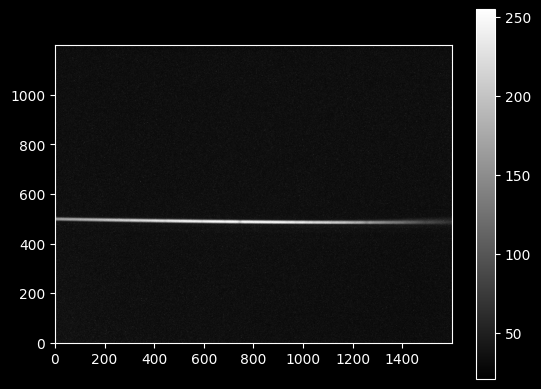

In [3]:
spectrum_filename = "aldebaran_3s_1.bmp"
image_array_2 = np.array(Image.open('deneb_3s_13.63g_1.bmp'))
plt.imshow(image_array_2, cmap='gray')
plt.colorbar();

In [4]:
image_data = Image.open(spectrum_filename)

Se define una variable que almacena el nombre del archivo de imagen (en este caso, un archivo BMP).

Ahora la imagen un objeto de tipo PIL.Image.Image, lo que significa que se puede manipular la imagen usando los métodos de PIL, como cambiar su formato, tamaño o convertirla en una matriz NumPy.

Finalmente se muestra la imagen en pantalla automáticamente.

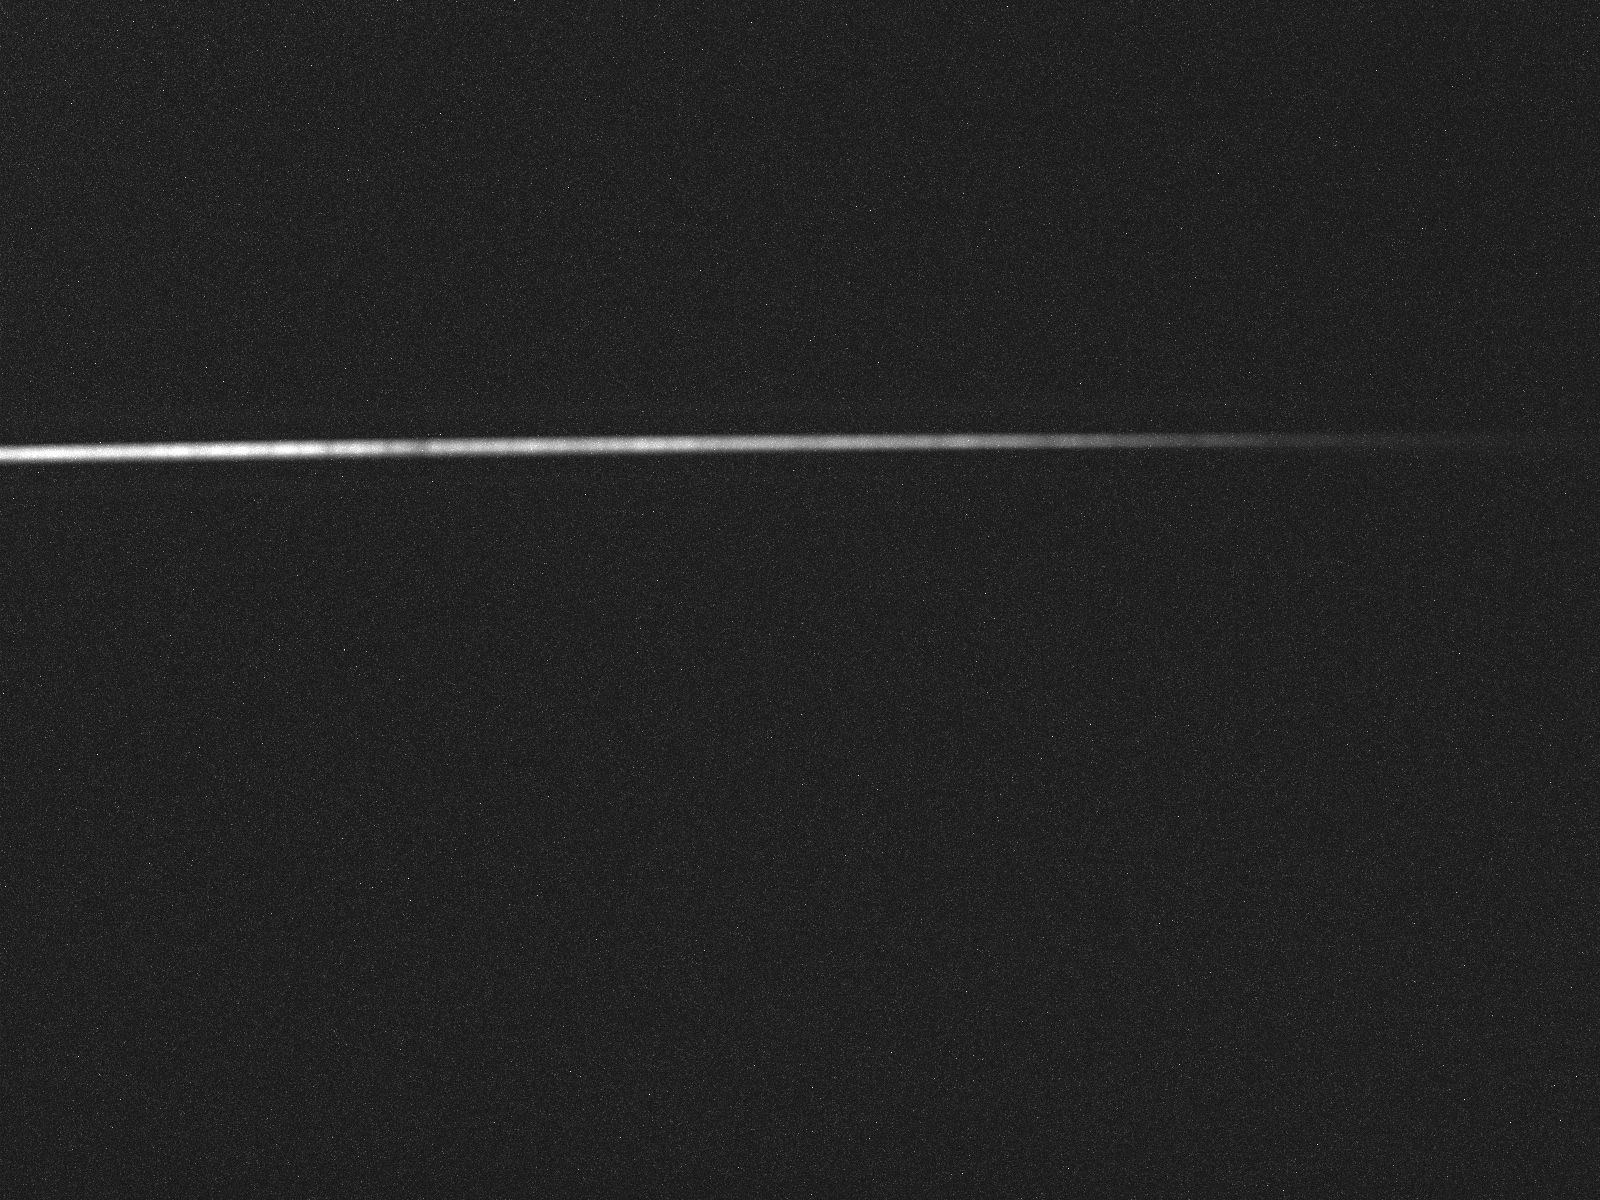

In [5]:
image_data

In [6]:
image_array = np.array(image_data)
image_array, image_array.shape

(array([[41, 43, 50, ..., 52, 28, 27],
        [33, 22, 48, ..., 37, 35, 26],
        [41, 64, 30, ..., 21, 30, 33],
        ...,
        [33, 28, 27, ..., 26, 33, 28],
        [35, 25, 23, ..., 23, 46, 46],
        [32, 35, 22, ..., 23, 40, 29]], shape=(1200, 1600), dtype=uint8),
 (1200, 1600))

Aquí se convierte la imagen en un array NumPy. Este array representa la imagen en forma de una matriz de píxeles, que tendrá la forma (alto, ancho).


Muestra la imagen almacenada en image_data, cmap='gray' indica que la imagen debe visualizarse en escala de grises.

Se agrega una barra de colores al lado de la imagen, lo cual es útil cuando se trata de datos de intensidad o imágenes en escala de grises.

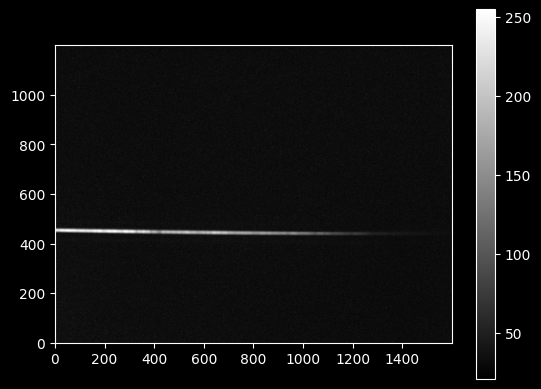

In [7]:
plt.imshow(image_data, cmap='gray')
plt.colorbar()

El objetivo es obtener un modelo f(x) que describa la posición vertical de la señal en la imagen, Comenzaremos asumiendo que la dispersión de la longitud de onda se produce en la dirección X y que la dirección Y es completamente espacial.

# Paso 2: Intentar encontrar la estructura central para trazar usando argmax.

Para obtener la traza, primero medimos el valor Y en cada valor X. Comenzaremos con el enfoque trivial de usar argmax:

In [8]:
yvals = np.argmax(image_data, axis=0)
xvals = np.arange(image_data.width)

Este código está tratando de encontrar la posición de la señal en función de la coordenada X, basándose en la imagen del espectro.

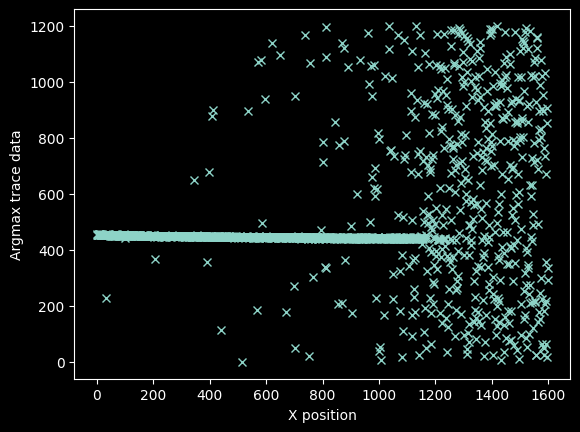

In [9]:
plt.plot(xvals, yvals, 'x')
plt.ylabel("Argmax trace data")
plt.xlabel("X position");

Ahora se debe identifcar los pixeles que no se encuentran en la linea principal de la traza y eliminarlos.

In [10]:
bad_pixels = (yvals < 400) | (yvals > 500)

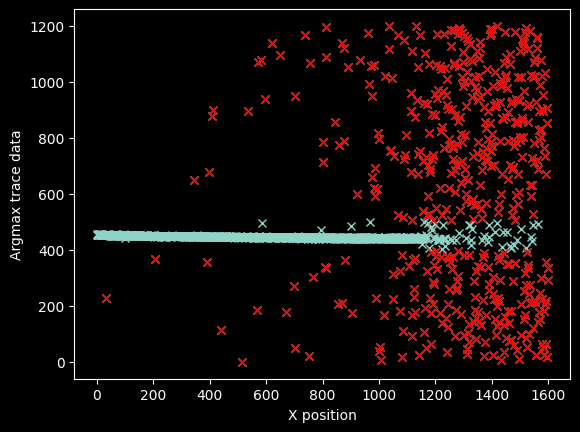

In [11]:
plt.plot(xvals, yvals, 'x')
plt.plot(xvals[bad_pixels], yvals[bad_pixels], 'rx')
plt.ylabel("Argmax trace data")
plt.xlabel("X position");

HAciendo un zoom despues de eliminado los pixeles malos   podemos ver la siguente grafica 

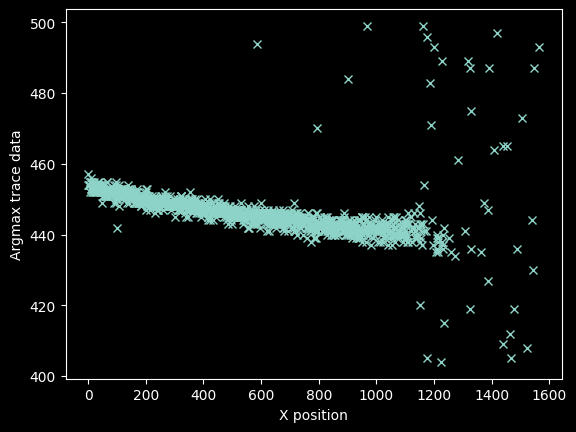

In [12]:
plt.plot(xvals[~bad_pixels], yvals[~bad_pixels], 'x')
plt.ylabel("Argmax trace data")
plt.xlabel("X position");

In [13]:
bad_pixels = (yvals < 425) | (yvals > 460)

Haciendo un zoom mas grande 

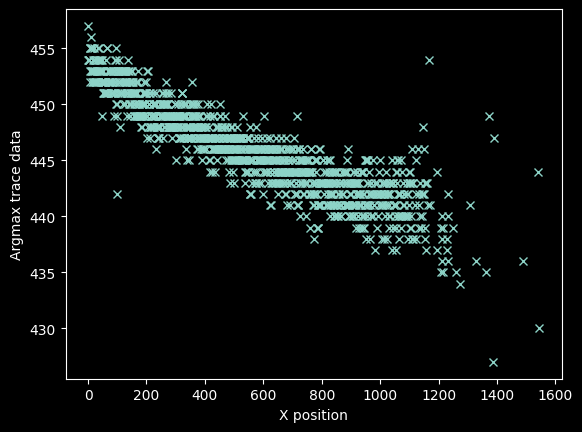

In [14]:
plt.plot(xvals[~bad_pixels], yvals[~bad_pixels], 'x')
plt.ylabel("Argmax trace data")
plt.xlabel("X position");

plt.gca() obtiene el objeto Axes actual.
.set_aspect(10) establece la relación de aspecto en 10, lo que significa que las unidades en el eje y se mostrarán 10 veces más grandes que en el eje x.
Esto distorsiona la imagen estirándola verticalmente.

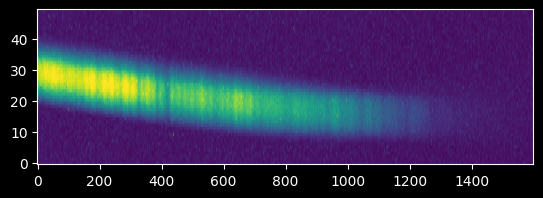

In [15]:
plt.imshow(image_array[425:475,:])
plt.gca().set_aspect(10)

# Paso 2.1 : Utiliza el análisis de momentos para extraer una estructura central a trazar.


In [59]:
yaxis = np.repeat(np.arange(425, 475)[:,None],
                  image_array.shape[1], axis=1)
background = np.median(image_array)
# moment 1 is the data-weighted average of the Y-axis coordinates
weighted_yaxis_values = np.average(yaxis, axis=0,
                                   weights=image_array[425:475,:] - background)

np.arange(425, 475)[:,None] genera una matriz columna con valores de 425 a 474 (50 filas y 1 columna).
Se obtiene una matriz donde cada fila contiene un valor fijo del rango [425, 474] (representando coordenadas en el eje Y), y este valor se repite a lo largo de todas las columnas de image_array.
Calcula la mediana de todos los valores de image_array, que se usará como referencia para calcular pesos en el siguiente paso.
weighted_yaxis_values es un vector de tamaño (image_array.shape[1],), que representa el centroide ponderado de las coordenadas en el eje Y para cada columna de la imagen.

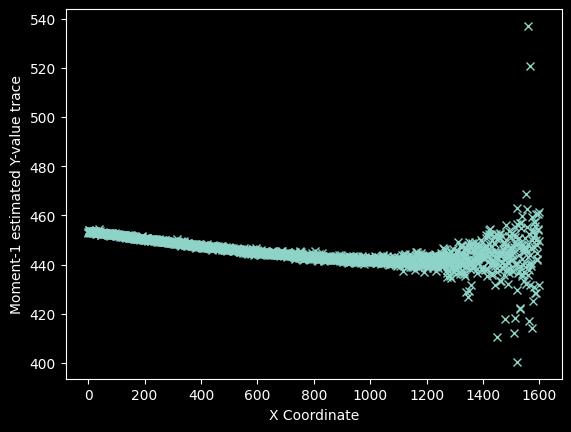

In [17]:
plt.plot(xvals, weighted_yaxis_values, 'x')
plt.xlabel("X Coordinate")
plt.ylabel("Moment-1 estimated Y-value trace");

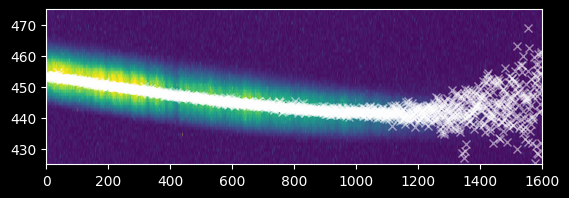

In [18]:
plt.imshow(image_array[425:475,:],
          extent=[0,image_array.shape[1],425,475])
plt.gca().set_aspect(10) # we stretch the image out by 10x in the y-direction
plt.plot(xvals, weighted_yaxis_values, 'wx', alpha=0.5)
plt.axis((0,1600,425,475));

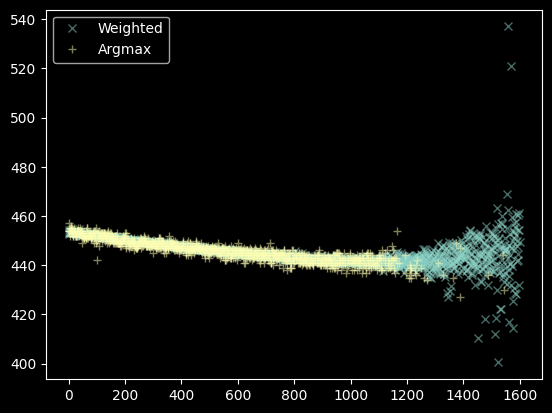

In [19]:
plt.plot(xvals, weighted_yaxis_values, 'x', label="Weighted", alpha=0.5)
plt.plot(xvals[~bad_pixels], yvals[~bad_pixels], '+', label="Argmax", alpha=0.5)
plt.legend(loc='best');

In [20]:
bad_moments = (weighted_yaxis_values > 460) | (weighted_yaxis_values < 430)

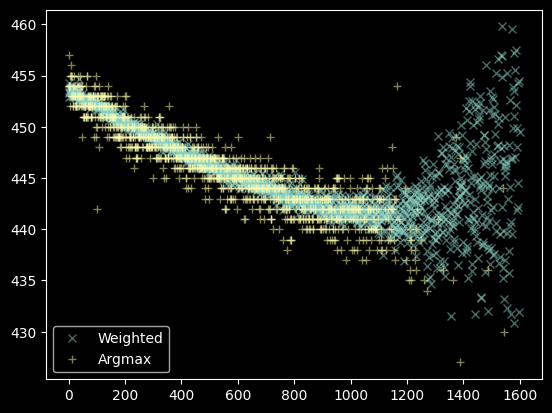

In [21]:
plt.plot(xvals[~bad_moments], weighted_yaxis_values[~bad_moments], 'x', label="Weighted", alpha=0.5)
plt.plot(xvals[~bad_pixels], yvals[~bad_pixels], '+', label="Argmax", alpha=0.5)
plt.legend(loc='best');

#Paso 3: Ajustar el perfil de la traza.

In [22]:
from astropy.modeling.polynomial import Polynomial1D
from astropy.modeling.fitting import LinearLSQFitter

In [23]:
polymodel = Polynomial1D(degree=2)
linfitter = LinearLSQFitter()
fitted_polymodel = linfitter(polymodel, xvals[~bad_moments], weighted_yaxis_values[~bad_moments])

In [24]:
fitted_polymodel

<Polynomial1D(2, c0=454.80138106, c1=-0.02381282, c2=0.00001121)>

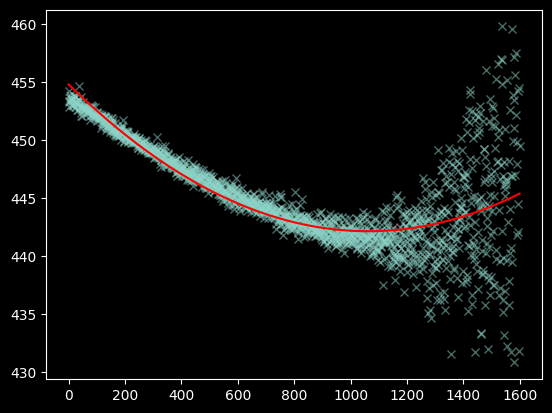

In [25]:
plt.plot(xvals[~bad_moments], weighted_yaxis_values[~bad_moments], 'x', alpha=0.5)
plt.plot(xvals, fitted_polymodel(xvals), color='r');

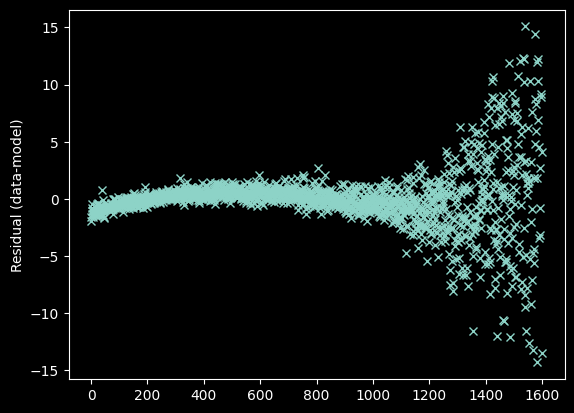

In [26]:
plt.plot(xvals[~bad_moments],
        weighted_yaxis_values[~bad_moments] - fitted_polymodel(xvals[~bad_moments]), 'x')
plt.ylabel("Residual (data-model)");

In [27]:
polymodel = Polynomial1D(degree=3)
fitted_polymodel = linfitter(polymodel, xvals[~bad_moments], weighted_yaxis_values[~bad_moments])
fitted_polymodel

<Polynomial1D(3, c0=453.31622273, c1=-0.01256666, c2=-0.00000651, c3=0.00000001)>

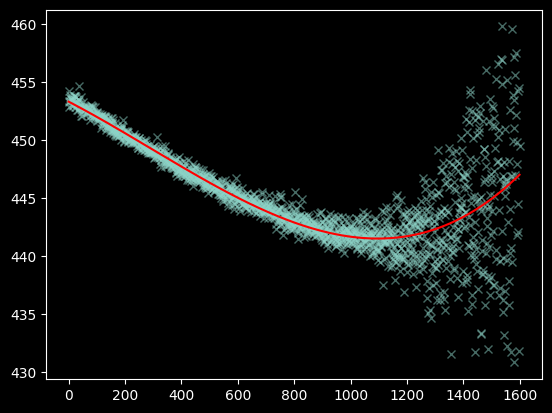

In [28]:
plt.plot(xvals[~bad_moments], weighted_yaxis_values[~bad_moments], 'x', alpha=0.5)
plt.plot(xvals, fitted_polymodel(xvals), color='r');

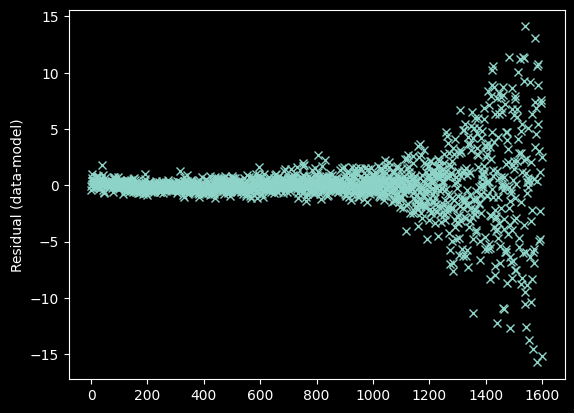

In [29]:
plt.plot(xvals[~bad_moments],
      weighted_yaxis_values[~bad_moments] - fitted_polymodel(xvals[~bad_moments]), 'x')
plt.ylabel("Residual (data-model)");

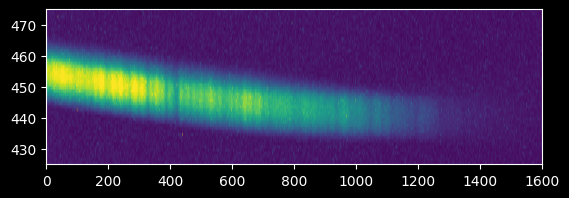

In [30]:
plt.imshow(image_array[425:475,:],
          extent=[0,image_array.shape[1],425,475])
plt.gca().set_aspect(10);

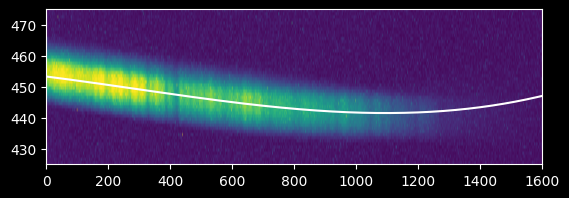

In [31]:
plt.imshow(image_array[425:475,:], extent=[0,image_array.shape[1],425,475])
plt.gca().set_aspect(10)
plt.plot(xvals, fitted_polymodel(xvals), 'w')
plt.axis((0,1600,425,475));

In [32]:
polymodel = Polynomial1D(degree=3)
fitted_polymodel = linfitter(polymodel, xvals[(~bad_moments) & (xvals < 1200)],
                             weighted_yaxis_values[(~bad_moments) & (xvals < 1200)])
fitted_polymodel

<Polynomial1D(3, c0=453.63074008, c1=-0.01596396, c2=0.00000083, c3=0.)>

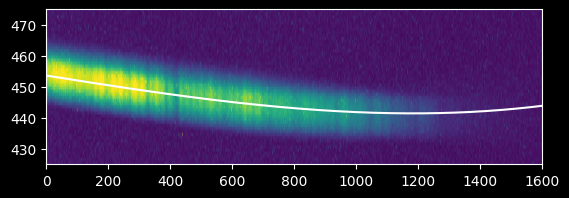

In [33]:
plt.imshow(image_array[425:475,:], extent=[0,image_array.shape[1],425,475])
plt.gca().set_aspect(10)
plt.plot(xvals, fitted_polymodel(xvals), 'w')
plt.axis((0,1600,425,475));

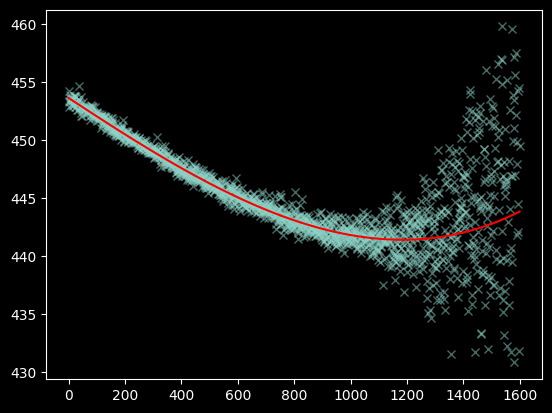

In [34]:
plt.plot(xvals[~bad_moments], weighted_yaxis_values[~bad_moments], 'x', alpha=0.5)
plt.plot(xvals, fitted_polymodel(xvals), color='r');

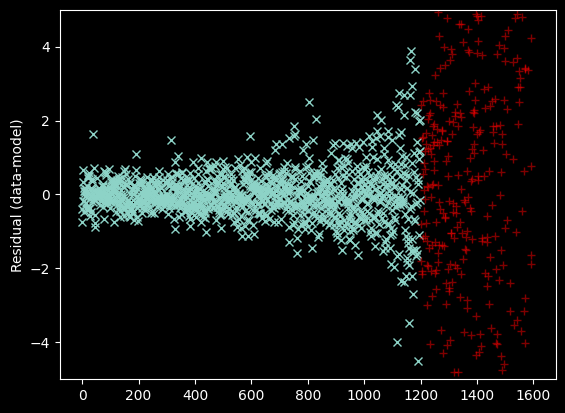

In [35]:
plt.plot(xvals[~bad_moments & (xvals < 1200)],
        weighted_yaxis_values[~bad_moments & (xvals < 1200)] - fitted_polymodel(xvals[~bad_moments & (xvals < 1200)]), 'x')
plt.plot(xvals[~bad_moments & (xvals > 1200)],
        weighted_yaxis_values[~bad_moments & (xvals > 1200)] - fitted_polymodel(xvals[~bad_moments & (xvals > 1200)]), 'r+', alpha=0.5)
plt.ylim(-5, 5)
plt.ylabel("Residual (data-model)");

#Paso 4 : Crear un perfil de la traza.


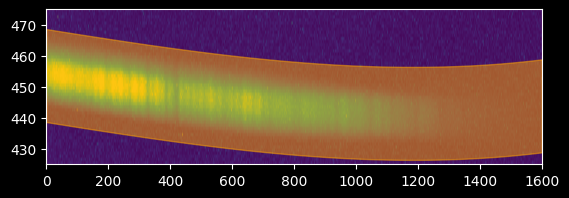

In [36]:
plt.imshow(image_array[425:475,:], extent=[0,image_array.shape[1],425,475])
plt.gca().set_aspect(10)
plt.fill_between(xvals, fitted_polymodel(xvals)-15,
                fitted_polymodel(xvals)+15,
                color='orange', alpha=0.5)
plt.axis((0,1600,425,475));

In [37]:
npixels_to_cut = 15
trace_center = fitted_polymodel(xvals)
cutouts = np.array([image_array[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii]
                    for yval, ii in zip(trace_center, xvals)])
cutouts.shape

(1600, 30)

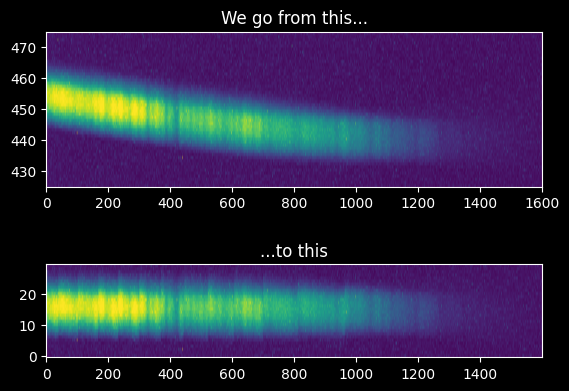

In [38]:
ax1 = plt.subplot(2,1,1)
ax1.imshow(image_array[425:475,:], extent=[0,image_array.shape[1],425,475])
ax1.set_aspect(10)
ax1.set_title("We go from this...")
ax2 = plt.subplot(2,1,2)
ax2.imshow(cutouts.T)
ax2.set_title("...to this")
ax2.set_aspect(10)

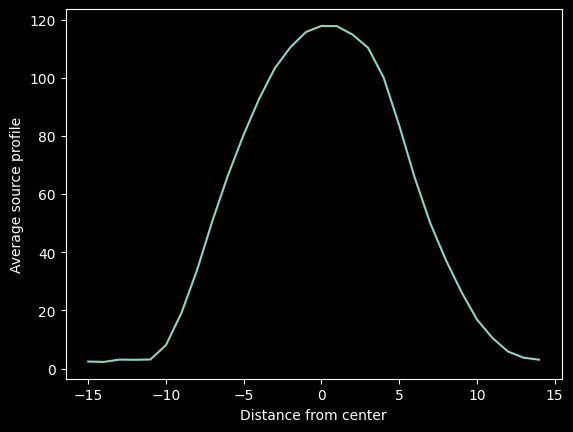

In [39]:
mean_trace_profile = (cutouts - background).mean(axis=0)
trace_profile_xaxis = np.arange(-npixels_to_cut, npixels_to_cut)
plt.plot(trace_profile_xaxis, mean_trace_profile)
plt.xlabel("Distance from center")
plt.ylabel("Average source profile");

In [40]:
from astropy.modeling.models import Gaussian1D
from astropy.modeling.fitting import LevMarLSQFitter
lmfitter = LevMarLSQFitter()
guess = Gaussian1D(amplitude=mean_trace_profile.max(), mean=0, stddev=5)
fitted_trace_profile = lmfitter(model=guess, x=trace_profile_xaxis, y=mean_trace_profile)
model_trace_profile = fitted_trace_profile(trace_profile_xaxis)
fitted_trace_profile

ModuleNotFoundError: No module named 'scipy'

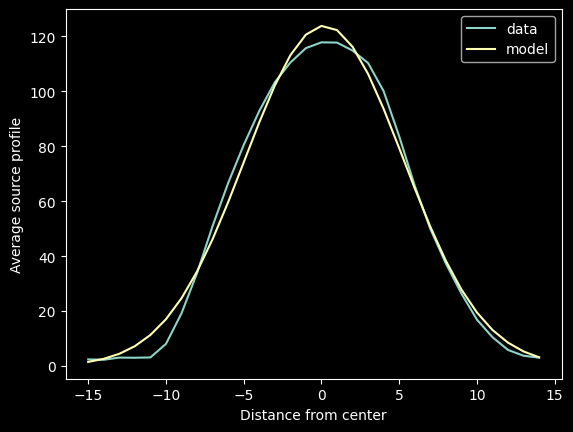

In [ ]:
plt.plot(trace_profile_xaxis, mean_trace_profile, label='data')
plt.plot(trace_profile_xaxis, model_trace_profile, label='model')
plt.legend(loc='best')
plt.xlabel("Distance from center")
plt.ylabel("Average source profile");

# Paso 5 : Sacar espectro de la traza


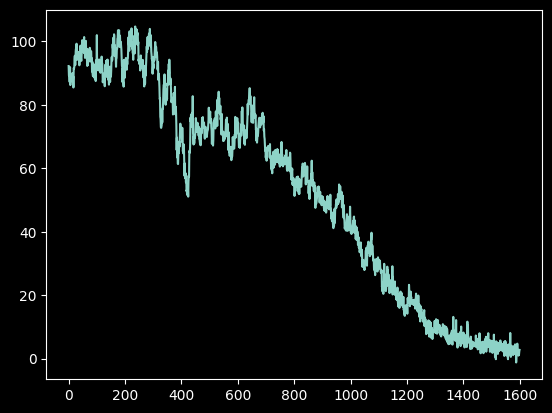

In [47]:
average_spectrum = (cutouts - background).mean(axis=1)
plt.plot(average_spectrum);

In [ ]:
trace_avg_spectrum = np.array([np.average(
    image_array[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii] - background,
    weights=mean_trace_profile)
                               for yval, ii in zip(trace_center, xvals)])

In [46]:
gaussian_trace_avg_spectrum = np.array([np.average(
    image_array[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii] - background,
    weights=model_trace_profile)
                               for yval, ii in zip(trace_center, xvals)])

NameError: name 'model_trace_profile' is not defined

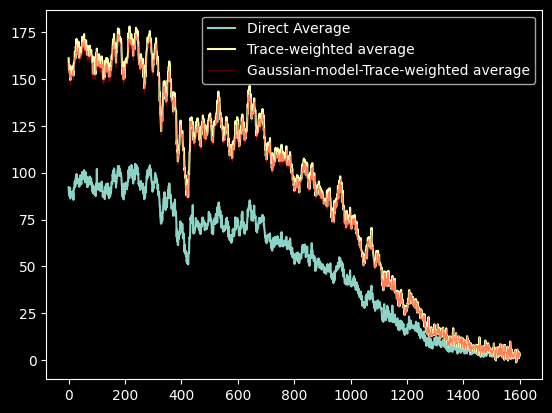

In [ ]:
plt.plot(average_spectrum, label="Direct Average")
plt.plot(trace_avg_spectrum, label='Trace-weighted average')
plt.plot(gaussian_trace_avg_spectrum, label='Gaussian-model-Trace-weighted average', alpha=0.5, linewidth=0.5, color='r')
plt.legend(loc='best');

#Ahora para mas estrellas:

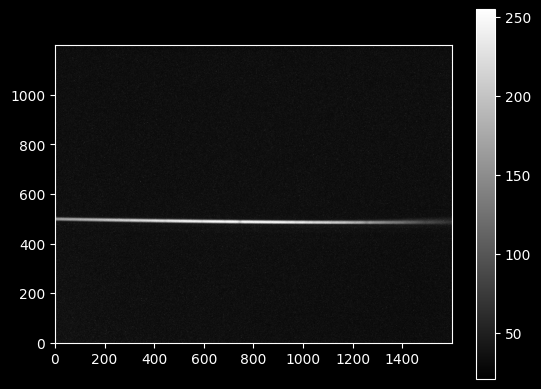

In [ ]:
image_array_2 = np.array(Image.open('deneb_3s_13.63g_1.bmp'))
plt.imshow(image_array_2, cmap='gray')
plt.colorbar();

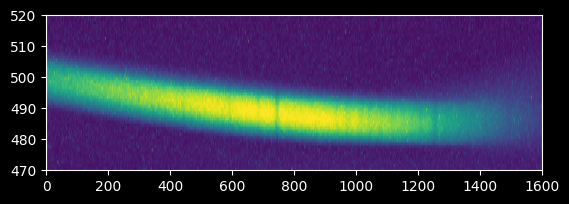

In [ ]:
plt.imshow(image_array_2[470:520,:], extent=[0,1600,470,520])
plt.gca().set_aspect(10)

In [ ]:
yaxis2 = np.repeat(np.arange(470, 520)[:,None], image_array_2.shape[1], axis=1)
weighted_yaxis_values2 = np.average(yaxis2, axis=0, weights=image_array_2[470:520,:] - np.median(image_array_2))
polymodel2 = Polynomial1D(degree=3)
fitted_polymodel2 = linfitter(polymodel2, xvals, weighted_yaxis_values2)
trace_center2 = fitted_polymodel2(xvals)

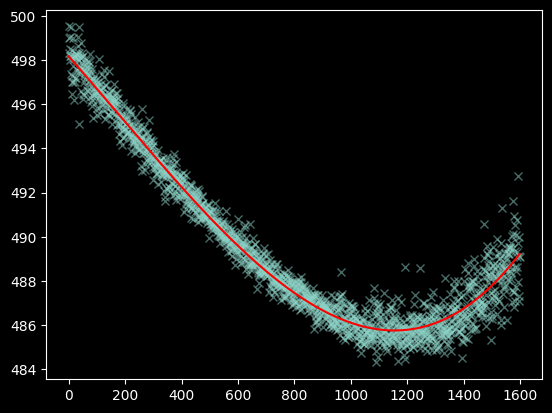

In [ ]:
plt.plot(xvals, weighted_yaxis_values2, 'x', alpha=0.5)
plt.plot(xvals, trace_center2, color='r');

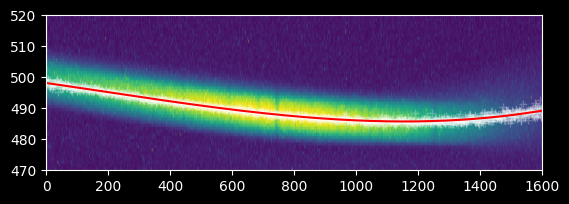

In [ ]:
plt.imshow(image_array_2[470:520,:], extent=[0,1600,470,520])
plt.plot(xvals, weighted_yaxis_values2, 'w+', alpha=0.25)
plt.plot(xvals, trace_center2, color='r')
plt.gca().set_aspect(10)

In [ ]:
spectrum2 = np.array([np.average(image_array_2[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii] - np.median(image_array_2),
                                weights=mean_trace_profile)
                     for yval, ii in zip(trace_center2, xvals)])

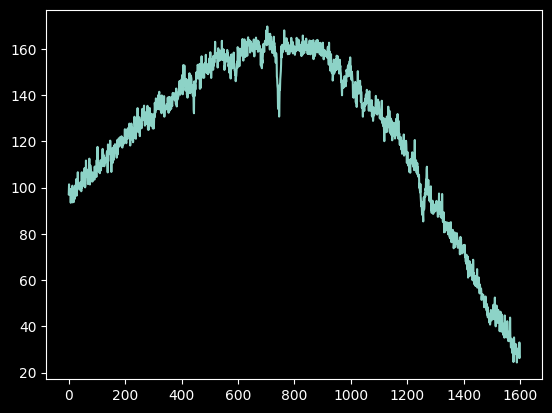

In [ ]:
plt.plot(spectrum2);

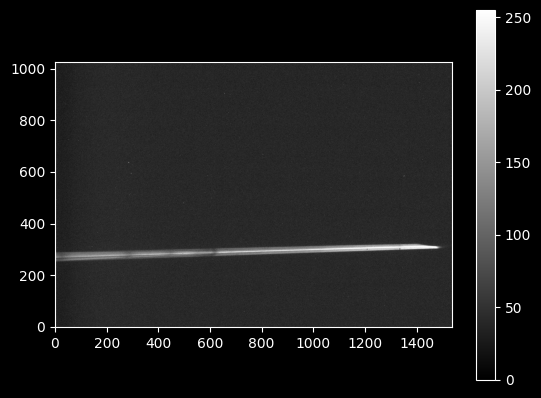

In [ ]:
image_array_3 = np.array(Image.open('vega_2.bmp').convert("L"))
plt.imshow(image_array_3, cmap='gray')
plt.colorbar();

(1600,) (1536,)


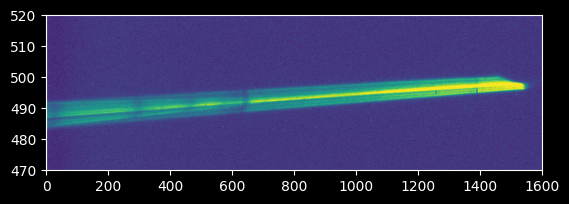

In [ ]:
plt.imshow(image_array_3[200:400,:], extent=[0,1600,470,520])
plt.gca().set_aspect(10)



In [ ]:
xvals = np.arange(image_array_3.shape[1])
yaxis3 = np.repeat(np.arange(200, 400)[:,None], image_array_3.shape[1], axis=1)
weighted_yaxis_values3 = np.average(yaxis3, axis=0, weights=image_array_3[200:400,:] - np.median(image_array_3))
polymodel3 = Polynomial1D(degree=3)
fitted_polymodel3 = linfitter(polymodel3, xvals, weighted_yaxis_values3)
trace_center3 = fitted_polymodel3(xvals)




In [ ]:
print(yaxis3.shape)
print((image_array_3[200:400, :] - np.median(image_array_3)).shape)


(200, 1536)
(200, 1536)


In [52]:
image_array_4 = np.array(Image.open('Mercurio.jpeg').convert("L"))

In [57]:
primg_height, img_width = image_array_4.shape


In [58]:
img_height, img_width = image_array_4.shape

# Asegurar que los índices están dentro del rango de la imagen
start = min(470, img_height - 1)  # Asegurar que start no sea mayor que el tamaño de la imagen
end = min(520, img_height)  # Asegurar que end no supere la altura de la imagen

# Verificar si hay suficientes filas para el procesamiento
if end <= start:
    raise ValueError(f"La imagen tiene solo {img_height} filas, y el rango [{start}:{end}] no es válido.")

# Crear el eje Y y calcular los pesos
yaxis2 = np.repeat(np.arange(start, end)[:, None], img_width, axis=1)
weights = np.abs(image_array_4[start:end, :] - np.median(image_array_4[start:end, :]))

# Verificar formas antes de continuar
print("yaxis2 shape:", yaxis2.shape)
print("weights shape:", weights.shape)

# Verificar valores de weights
if np.isnan(weights).any():
    print("¡Cuidado! Se encontraron valores NaN en los pesos. Se reemplazarán con 0.")
    weights = np.nan_to_num(weights, nan=0)

if np.sum(weights) == 0:
    print("Advertencia: Todos los valores de weights son 0. Se agregará un pequeño desplazamiento.")
    weights += 1e-6  # Evitar pesos cero

# Calcular promedio ponderado
weighted_yaxis_values2 = np.average(yaxis2, axis=0, weights=weights)

# Ajuste polinómico
polymodel2 = models.Polynomial1D(degree=3)
linfitter = fitting.LinearLSQFitter()
xvals = np.arange(img_width)
fitted_polymodel2 = linfitter(polymodel2, xvals, weighted_yaxis_values2)

# Centro de la traza
trace_center2 = fitted_polymodel2(xvals)

yaxis2 shape: (1, 592)
weights shape: (1, 592)


ZeroDivisionError: Weights sum to zero, can't be normalized

In [49]:
yaxis2 = np.repeat(np.arange(470, 520)[:,None], image_array_4.shape[1], axis=1)
weighted_yaxis_values2 = np.average(yaxis2, axis=0, weights=image_array_4[470:520,:] - np.median(image_array_4))
polymodel2 = Polynomial1D(degree=3)
fitted_polymodel2 = linfitter(polymodel2, xvals, weighted_yaxis_values2)
trace_center2 = fitted_polymodel2(xvals)

ValueError: Shape of weights must be consistent with shape of a along specified axis.